
In this session we learn probability using simple experiments:

1. Coin toss
2. Dice roll
3. Basic conditional probability
4. Independence vs dependence
5. Simple distribution visuals
6. Small ML style example


**Goal:**
Build intuition with simple code and visuals.

In [1]:
# Install required packages
%pip install numpy pandas matplotlib -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

**1. Coin Toss Simulation**

In [5]:
n = 500

outcomes = np.random.choice(["H", "T"], size=n)

heads = np.sum(outcomes == "H")
tails = np.sum(outcomes == "T")

print("Heads:", heads)
print("Tails:", tails)
print("Estimated P(Heads):", heads/n)
print("Estimated P(Tails):", tails/n)

Heads: 263
Tails: 237
Estimated P(Heads): 0.526
Estimated P(Tails): 0.474


**2. Dice roll simulation**

Estimated P(4): 0.183
values: [1 2 3 4 5 6]
counts: [175 134 175 183 168 165]
------------------------------


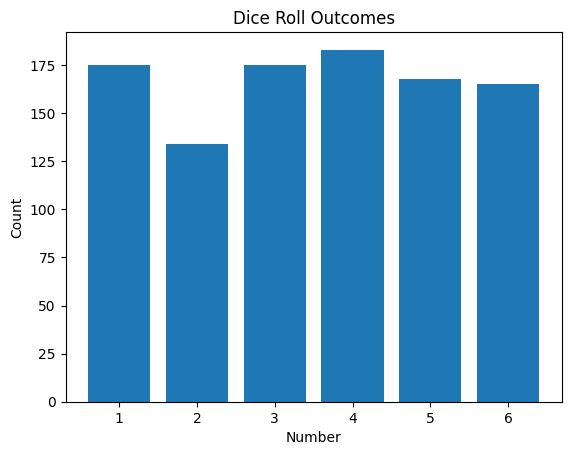

In [8]:
n = 1000

dice = np.random.randint(1, 7, size=n)

p_four = np.mean(dice == 4)

print("Estimated P(4):", p_four)

vals, counts = np.unique(dice, return_counts=True)

print("values:", vals)
print("counts:", counts)
print("-" * 30)
plt.bar(vals, counts)

plt.title("Dice Roll Outcomes")
plt.xlabel("Number")
plt.ylabel("Count")
plt.show()

**3. Conditional Probability**

We create a tiny dataset of 100 students.
Each student may like ML or not.
If they like ML, they are more likely to like DL as well.
Then we compute:
P(ML), P(DL), P(DL | ML)

In [10]:
data = pd.DataFrame({
    "likes_ML": np.random.choice([1, 0], size=100, p=[0.6, 0.4])
})

# DL depends on whether the student likes ML
data["likes_DL"] = [
    np.random.choice([1, 0], p=[0.7, 0.3]) if ml else
    np.random.choice([1, 0], p=[0.2, 0.8])
                     for ml in data["likes_ML"]
]

p_ml = data["likes_ML"].mean()
p_dl = data["likes_DL"].mean()
p_dl_given_ml = data[data["likes_ML"] == 1]["likes_DL"].mean()


print("P(ML):", round(p_ml, 2))
print("P(DL):", round(p_dl, 2))
print("P(DL | ML):", round(p_dl_given_ml, 2))

P(ML): 0.62
P(DL): 0.58
P(DL | ML): 0.74


**4. Independence vs Dependence**

Independent example: two separate dice.

Dependent example: DL depends on ML from our dataset.

In [11]:
die1 = np.random.randint(1, 7, size=500)
die2 = np.random.randint(1, 7, size=500)

print("\nP(die1 == 6):", np.mean(die1 == 6))
print("P(die2 == 6):", np.mean(die2 == 6))

print("P(DL | ML):", round(p_dl_given_ml, 2))


P(die1 == 6): 0.162
P(die2 == 6): 0.196
P(DL | ML): 0.74


**5. Distribution Shapes**

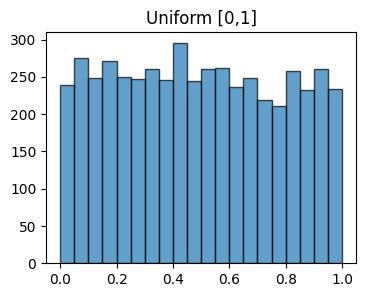

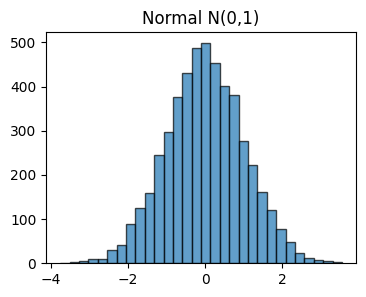

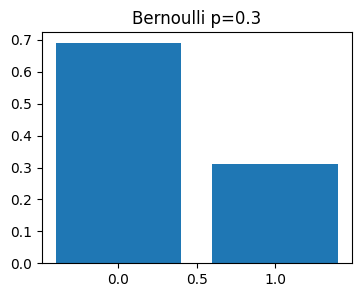

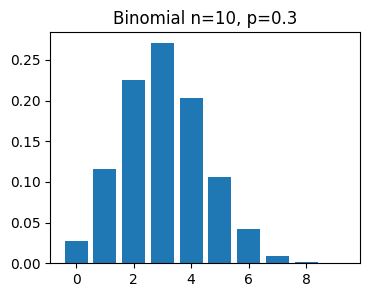

In [12]:
n = 5000

# Uniform
plt.figure(figsize=(4,3))
plt.hist(np.random.uniform(0, 1, n), bins=20, alpha=0.7, edgecolor="k")
plt.title("Uniform [0,1]")
plt.show()

# Normal N(0,1)
plt.figure(figsize=(4,3))
plt.hist(np.random.normal(0, 1, n), bins=30, alpha=0.7, edgecolor="k")
plt.title("Normal N(0,1)")
plt.show()

# Bernoulli p=0.3
plt.figure(figsize=(4,3))
vals, counts = np.unique(np.random.binomial(1, 0.3, n), return_counts=True)
plt.bar(vals, counts/n)
plt.title("Bernoulli p=0.3")
plt.show()

# Binomial n=10, p=0.3
plt.figure(figsize=(4,3))
vals, counts = np.unique(np.random.binomial(10, 0.3, n), return_counts=True)
plt.bar(vals, counts/n)
plt.title("Binomial n=10, p=0.3")
plt.show()

**6. Small ML Style Example**

ML classification models give probability scores.

Here we simulate probabilities and convert them into Yes or No labels.

In [18]:
preds = np.random.rand(10)
print("Model's prediction probability", preds)

print("-" * 30)

labels = preds > 0.5
print("Labels (Probability > 0.5)")
print(labels)

Model's prediction probability [0.9763129  0.22724809 0.19283117 0.67668563 0.41468389 0.02422234
 0.34686187 0.80674474 0.79742693 0.49468515]
------------------------------
Labels (Probability > 0.5)
[ True False False  True False False False  True  True False]
